In [1]:
import numpy as np
import pandas as pd
import qstudy as qs
from qstudy import Study
from qstudy.constants import SP500
import matplotlib.pyplot as plt

In [2]:
start_date = "2015-01-01"
end_date = "2023-12-31"
universe = qs.download(SP500, start_date, end_date)
factors = qs.download(
    ["SPY", "XLK"],
    start_date,
    end_date,
)
benchmark = qs.download("SPY", start_date, end_date)
returns_df = universe.returns
close_df = universe.close
volume_df = universe.volume
factor_returns = factors.returns
benchmark_returns = benchmark.returns
sector_map = qs.get_sector_map(SP500)

$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")

2 Failed downloads:
['SOLV', 'GEV']: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")


In [3]:
residuals_df, factor_params, factor_rsq = qs.residualize(returns_df, factor_returns)

In [4]:
print(residuals_df.isna().sum().sum())
print(residuals_df.shape)

0
(2264, 461)


after vol_filter: 275.3904593639576
after volume_zscore: 43.32994699646643
after momentum: 18.677120141342755
after liquidity: 9.458480565371024
after liquidity notna: 9.458480565371024
positions:  (2264, 461)
positions non-zero per day (sample): Date
2023-12-15    25
2023-12-18    17
2023-12-19    16
2023-12-20    12
2023-12-21    13
2023-12-22     7
2023-12-26     7
2023-12-27    16
2023-12-28    10
2023-12-29    17
dtype: int64
positions abs sum per day (sample): Date
2023-12-15    1.0
2023-12-18    1.0
2023-12-19    1.0
2023-12-20    1.0
2023-12-21    1.0
2023-12-22    1.0
2023-12-26    1.0
2023-12-27    1.0
2023-12-28    1.0
2023-12-29    1.0
dtype: float64
sharpe                              1.356697
ann_return                          0.193867
ann_vol                             0.137633
max_drawdown                       -0.187616
max_drawdown_duration                    197
max_drawdown_start       2023-02-21 00:00:00
max_drawdown_end         2023-11-30 00:00:00
avg_daily_turn

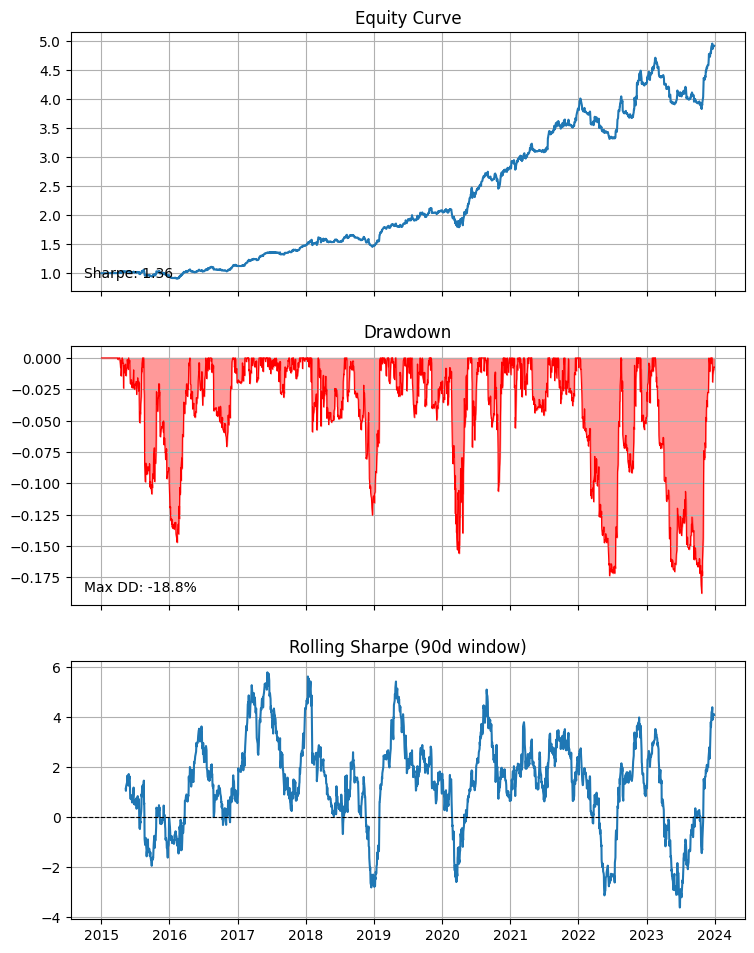

In [5]:
# -------------------------------------------------------------------
# residual mean reversion base signal
# -------------------------------------------------------------------
signal = -residuals_df.rolling(5).mean().shift(1)
signal = signal.sub(signal.mean(axis=1), axis=0)

# -------------------------------------------------------------------
# conditioning filters
# -------------------------------------------------------------------
signal = qs.vol_filter(signal, residuals_df, vol_window=5, quantile=0.6)
print("after vol_filter:", signal.notna().sum(axis=1).mean())

signal = qs.volume_zscore_filter(signal, volume_df, window=30, min_zscore_quantile=0.8)
print("after volume_zscore:", signal.notna().sum(axis=1).mean())

med_mom = residuals_df.rolling(60).mean()
signal = signal.where(med_mom.abs().lt(med_mom.quantile(0.7, axis=1), axis=0))
print("after momentum:", signal.notna().sum(axis=1).mean())

# -------------------------------------------------------------------
# liquidity universe
# -------------------------------------------------------------------

liq_mask = qs.liquidity_filter(close_df, volume_df, top_n=250)
signal = signal.where(liq_mask)
print("after liquidity:", signal.notna().sum(axis=1).mean())
print("after liquidity notna:", signal_after_liq.notna().sum(axis=1).mean())

ret_filtered = returns_df.where(liq_mask)

# -------------------------------------------------------------------
# portfolio construction
# -------------------------------------------------------------------

positions = qs.build_long_short_positions(signal, n_long=25, n_short=25)

print('positions: ', positions.shape)
print("positions non-zero per day (sample):", (positions != 0).sum(axis=1).tail(10))
print("positions abs sum per day (sample):", positions.abs().sum(axis=1).tail(10))
# -------------------------------------------------------------------
# raw strategy returns
# -------------------------------------------------------------------

raw_port_ret = qs.run(positions, ret_filtered)

# -------------------------------------------------------------------
# equity curve regime filter
# if strategy equity < 100d MA:
# reduce exposure
# -------------------------------------------------------------------
equity_curve = (1 + raw_port_ret).cumprod()
equity_ma = equity_curve.rolling(20).mean()

# 50% exposure below MA
exposure_scale = pd.Series(np.where(equity_curve > equity_ma, 1.0, 0.25), index=equity_curve.index)

# for full shutdown instead:
# exposure_scale = np.where(equity_curve > equity_ma, 1.0, 0.0)

scaled_positions = positions.mul(exposure_scale.shift(1), axis=0)

# -------------------------------------------------------------------
# final returns
# -------------------------------------------------------------------
port_ret = qs.run(scaled_positions, ret_filtered)

# -------------------------------------------------------------------
# diagnostics
# -------------------------------------------------------------------

print(qs.metrics.summary(port_ret, scaled_positions, benchmark=benchmark_returns))

ax = qs.summary_plot(port_ret, figsize=(8, 10))

residual_mean_reversion:   0%|                                                                                                                     | 0/12 [00:00<?, ?it/s, stage=residualize]

Using factors for residuals...


residual_mean_reversion: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 16.51it/s, stage=metrics]


base_signal: avg notna = 460.2, last 3 = [461, 461, 461]
demean_signal: avg notna = 460.2, last 3 = [461, 461, 461]
fn: avg notna = 275.5, last 3 = [276, 276, 276]
fn: avg notna = 43.3, last 3 = [51, 39, 47]
fn: avg notna = 18.7, last 3 = [29, 20, 25]
liquidity(top_n=250): avg notna = 9.5, last 3 = [16, 10, 17]
sharpe                              1.358934
ann_return                          0.194264
ann_vol                             0.137654
max_drawdown                       -0.187616
max_drawdown_duration                    197
max_drawdown_start       2023-02-21 00:00:00
max_drawdown_end         2023-11-30 00:00:00
avg_daily_turnover                  1.132823
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706393
benchmark_corr                      0.656987
information_ratio                   0.430451


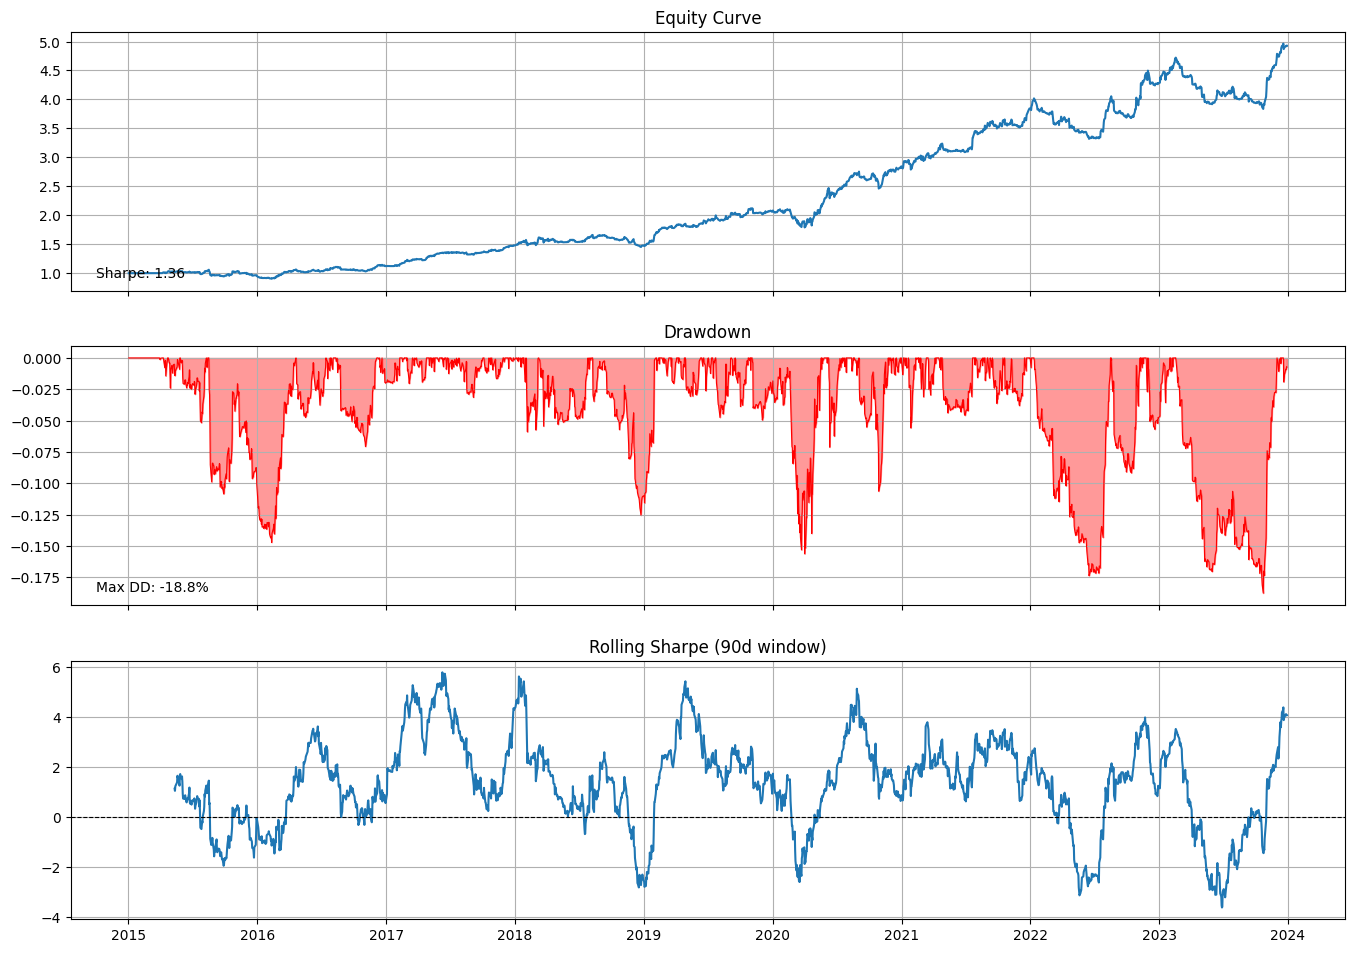

Study(name='residual_mean_reversion', steps=['base_signal', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'position_builder', 'position_scaler'], weighting=False, ran=True)

In [6]:
"""
Residual Mean Reversion — rewritten using the Study pipeline.

Original: manual steps using raw qstudy functions.
This version: same strategy expressed as a Study pipeline.

The equity-curve regime filter (scale to 0.25x when below 20-day MA)
is the one step that requires a custom function since it's not a
built-in filter. Everything else maps directly to pipeline methods.
"""

# ---------------------------------------------------------------------------
# Custom signal mutation
# ---------------------------------------------------------------------------
# The original code demeaned the signal after computing it:
#   signal = signal.sub(signal.mean(axis=1), axis=0)
# This is a signal mutation (not a filter), so we pass it as add_filter.
# We return the same shape — no cells are zeroed, just re-centered.

def demean_signal(signal, **cache):
    """Cross-sectionally demean the signal each day."""
    return signal.sub(signal.mean(axis=1), axis=0)

# ---------------------------------------------------------------------------
# Custom position scaler: equity-curve regime filter
# ---------------------------------------------------------------------------
# Scale positions to 0.25x when the cumulative equity curve is below its
# 20-day moving average, full exposure (1.0x) when above.

def equity_curve_regime_scale(positions, **cache):
    for name, sig in cache["_signal_history"]:
        notna = sig.notna().sum(axis=1)
        print(f"{name}: avg notna = {notna.mean():.1f}, last 3 = {notna.tail(3).tolist()}")
        
    returns = cache["returns"]
    
    mask = cache.get("_tradeable_mask")
    
    if mask is None:
        mask = cache.get("_liquidity_mask")
        
    if mask is not None:
        returns = returns.where(mask)
        
    # raw_ret = (positions * returns).sum(axis=1)
    raw_ret = (positions.shift(1) * returns).sum(axis=1)
    equity = (1 + raw_ret).cumprod()
    
    equity_ma = equity.rolling(20).mean()
    scale = pd.Series(np.where(equity > equity_ma, 1.0, 0.25), index=equity.index)

    return positions.mul(scale.shift(1), axis=0)


# ---------------------------------------------------------------------------
# Pipeline
# ---------------------------------------------------------------------------

study = (
    Study(
        universe=universe,
        benchmark=benchmark,
        factors=factors,
        name="residual_mean_reversion",
    )
    .residualize_returns()  # produces residual_returns in cache
    .mean_reversion(window=5)  # signal = -residuals.rolling(5).mean().shift(1)
    .transform_signal(demean_signal)  # signal = signal.sub(signal.mean(axis=1), axis=0)
    .add_vol_filter(vol_window=5, quantile=0.6)
    .add_volume_zscore_filter(window=30, min_zscore_quantile=0.8)
    .add_momentum_context_filter(window=60, max_abs_quantile=0.7)
    .add_tradeable_constraint(qs.liquidity(top_n=250, window=60))
    .build_long_short(n_long=25, n_short=25, rebalance_every=1)  # qs.build_long_short_positions(signal, 25, 25)
    .scale_risk(equity_curve_regime_scale)  # 0.25x exposure when below 20-day equity MA
    .run()
)

study.report()